In [1]:
building = 1
time = 20
price = 'Realistic'

battery_capacity = 9.0

# Setup

In [2]:
import torch
import pandas as pd
import numpy as np
import math

import src.data.dataprep as prep
import src.data.featurisation as features

from src.models.lstm import LSTM
from src.models.lstmopt import LSTMOPT
from src.models.lstmopt import CVXLayer

from src.training.training import  Training as Training
from src.training.training_opt import Training as Training_opt

import src.optimization.pv_battery as pvb

import src.tensors.tensorisation as tensor

import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error as mse

def torch_py(torch_tensor):
    return torch_tensor.cpu().detach().numpy().flatten()

def rescale(values, scaler):
    rescaled_values = values * (scaler[1] - scaler[0]) + scaler[0]   
    return rescaled_values

def assign_value(time, night, day):
    if time < pd.Timestamp("08:00:00").time() or time >= pd.Timestamp("19:00:00").time():
        return night
    else:
        return day

def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

In [3]:
# Import the base data and resample it from 5 minutes to hourly
nl_data = prep.dutch_data('../data/Dutchdata_clean/building_' + str(building) + '.parquet', 'h')
# Include net load for cost calculations
nl_data['net_load'] = nl_data['load'] - nl_data['solar_energy']
# Import a price profile and merge it with the consumption data

if price == 'Simple':
    # Simple profile
    nl_data.loc[:,'offtake'] = nl_data.index.to_series().apply(lambda x: assign_value(x.time(),0.2,0.3))
    nl_data.loc[:,'injection'] = nl_data.index.to_series().apply(lambda x: assign_value(x.time(),0.05,0.01))
elif price == 'Realistic':
    # Realistic profile
    nl_price_data = pd.read_csv('../data/NL_DA_Prices.csv', index_col='Date',parse_dates=True, dayfirst=True)
    nl_data = nl_data.merge(nl_price_data[['offtake', 'injection']], left_index=True, right_index=True)

# calculate the cost to be a positive net load x offtake minus a negative net load x injection
nl_data['cost'] = nl_data.apply(lambda row: row['net_load'] * row['injection'] if row['net_load'] < 0 else row['net_load'] * row['offtake'], axis=1)

In [4]:
featurisation = features.Featurisation(nl_data)
nl_data = featurisation.cyclic_features(yearly=False)[0]
nl_data.head()

,load,solar_energy,net_load,offtake,injection,cost,hour_sin,hour_cos
2018-07-01 00:00:00,0.556,0.0,0.556,0.18878,0.030,0.104962,0.000000,1.000000
2018-07-01 01:00:00,0.333,0.0,0.333,0.18178,0.024,0.060533,0.258819,0.965926
2018-07-01 02:00:00,0.347,0.0,0.347,0.17278,0.018,0.059955,0.500000,0.866025
2018-07-01 03:00:00,0.340,0.0,0.340,0.16278,0.010,0.055345,0.707107,0.707107
2018-07-01 04:00:00,0.289,0.0,0.289,0.16478,0.012,0.047621,0.866025,0.500000


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Parameters

In [6]:
# Base parameters
max_charge = battery_capacity/2.7
max_discharge = max_charge
layers = 3
neurons = 200
features = 3
train_test_split = 0.6

past_features = ['solar_energy']
future_features = ['hour_sin','hour_cos']
opt_future_features = ['hour_sin','hour_cos','load','offtake','injection']
domain_min = [None, None, None, 0, 0, 0, None]
domain_max = [None, None, None, 1, 1, 1, None]

In [7]:
pvb_system = pvb.PV_battery(nl_data, battery_capacity, max_charge, max_discharge, self_consumption=False)

In [8]:
problem, variables, parameters = pvb_system.create_optimization_problem(24)

# Previous problems

We first need the initial battery states for the hour prior to the current optimization as input for our current optimization. This requires looping over all previous timeslots, as every consecutive optimization needs the initial battery state coming from the previous one.

In [9]:
# We evaluate how many times we need to loop over the optimization
problems = 24 - time

In [12]:
# We keep the test initial batteries in this list
initial_battery_test_perfect = []
initial_battery_test_naive = []
initial_battery_test_lstm = []
initial_battery_test_cvx = []
initial_battery_test_lstm_cvx = []

pv_fcst_test_lstm = []
pv_fcst_test_cvx = []
pv_fcst_test_lstm_cvx = []

# These values get updated each loop
old_T = 24          # The first timeslot under consideration: 24 hours to optimize 
lags = 24           # The number of lags for this first timeslot: the 24 previous hours
forecast_gap = 0    # The gap after every forecast which is 0 when we need to forecast 24 hours

# loop over each of the problems
for i in range(problems):
       
    print('Setting up optimization for hour ' + str(i))
    
    # Get the optimization problem for the current problem
    problem, variables, parameters = pvb_system.create_optimization_problem(old_T)
    
    # Get what actually happens based on the (dis)charging scheme to obtain the initial battery value for the next hour
    problem_post, variables_post, parameters_post = pvb_system.create_post_forecast_optimization_problem(old_T)

    
    # Tensors for training a base forecaster
    tensors = tensor.Tensors(pvb_system.house,'solar_energy',past_features,future_features,lags,old_T, forecast_gap=forecast_gap,train_test_split=train_test_split)
    _, X_test, _, y_test, scalers = tensors.create_tensor()
    
    
    # Tensors for training an E2E network
    tensors_cvx = tensor.Tensors(pvb_system.house,'solar_energy',past_features,opt_future_features,lags,old_T, forecast_gap=forecast_gap, train_test_split=train_test_split, domain_min=domain_min, domain_max=domain_max)
    tensors_lstm_cvx = tensor.Tensors(pvb_system.house,'solar_energy',past_features,opt_future_features,lags,old_T, forecast_gap=forecast_gap, train_test_split=train_test_split, domain_min=domain_min, domain_max=domain_max)

    # We don't need the Y values as they are identical to the ones from the base forecaster
    _, X_test_perfect, _, _, scalers_perfect = tensors_cvx.create_tensor()
    _, X_test_naive, _, _, scalers_naive = tensors_cvx.create_tensor()
    _, X_test_lstm, _, _, scalers_lstm = tensors_cvx.create_tensor()
    _, X_test_cvx, _, _, scalers_cvx = tensors_cvx.create_tensor()
    _, X_test_lstm_cvx, _, _, scalers_lstm_cvx = tensors_lstm_cvx.create_tensor()

    # We have to assign initial battery values to the current optimization at hand, first we create an empty tensor
    initial_bat_tensor_test_perfect = torch.zeros([X_test_perfect.shape[0],lags,1])
    initial_bat_tensor_test_naive = torch.zeros([X_test_naive.shape[0],lags,1])
    initial_bat_tensor_test_lstm = torch.zeros([X_test_lstm.shape[0],lags,1])
    initial_bat_tensor_test_cvx = torch.zeros([X_test_cvx.shape[0],lags,1])
    initial_bat_tensor_test_lstm_cvx = torch.zeros([X_test_lstm_cvx.shape[0],lags,1])

    # If this is the first optimization done at midnight, the initial battery is set at 50% of the capacity, as we also make sure that the end
    # state of the battery from the previous day is 50%
    if i == 0:       
        initial_bat_tensor_test_perfect[:,-1,:] = battery_capacity * 0.5
        initial_bat_tensor_test_naive[:,-1,:] = battery_capacity * 0.5
        initial_bat_tensor_test_lstm[:,-1,:] = battery_capacity * 0.5
        initial_bat_tensor_test_cvx[:,-1,:] = battery_capacity * 0.5
        initial_bat_tensor_test_lstm_cvx[:,-1,:] = battery_capacity * 0.5

    # If it is not the first optimization, we obtain the initial battery values from the list of battery values we have been maintaining 
    else:
        initial_bat_tensor_test_perfect[:,-1,:] = torch.tensor(initial_battery_test_perfect[i-1]).unsqueeze(-1)
        initial_bat_tensor_test_naive[:,-1,:] = torch.tensor(initial_battery_test_naive[i-1]).unsqueeze(-1)
        initial_bat_tensor_test_lstm[:,-1,:] = torch.tensor(initial_battery_test_lstm[i-1]).unsqueeze(-1)
        initial_bat_tensor_test_cvx[:,-1,:] = torch.tensor(initial_battery_test_cvx[i-1]).unsqueeze(-1) 
        initial_bat_tensor_test_lstm_cvx[:,-1,:] = torch.tensor(initial_battery_test_lstm_cvx[i-1]).unsqueeze(-1)

    # We add this tensor to our X tensors for the E2E network
    X_test_perfect = torch.concat([X_test_perfect, initial_bat_tensor_test_perfect],dim=-1)
    X_test_naive = torch.concat([X_test_naive, initial_bat_tensor_test_naive],dim=-1)
    X_test_lstm = torch.concat([X_test_lstm, initial_bat_tensor_test_lstm],dim=-1)
    X_test_cvx = torch.concat([X_test_cvx, initial_bat_tensor_test_cvx],dim=-1)
    X_test_lstm_cvx = torch.concat([X_test_lstm_cvx, initial_bat_tensor_test_lstm_cvx],dim=-1)

    # Create the models for PV forecasts
    lstm = LSTM(features, neurons, layers, old_T, 0.5).to(device)
    cvx = LSTMOPT(features,neurons,layers,old_T,0.5,problem,parameters,variables,scalers_cvx[0]).to(device)
    lstm_cvx = LSTMOPT(features,neurons,layers,old_T,0.5,problem,parameters,variables,scalers_lstm_cvx[0]).to(device)

    lstm.load_state_dict(torch.load('../models/LSTM/building_' + str(building) + '_' + str(old_T) + 'h.pth'))
    cvx.load_state_dict(torch.load('../models/CVX/building_' + str(building) + '_' + str(old_T) + 'h_' + str(battery_capacity) + 'kwh.pth'))
    lstm_cvx.load_state_dict(torch.load('../models/LSTM_CVX/building_' + str(building) + '_' + str(old_T) + 'h_' + str(battery_capacity) + 'kwh.pth'))

    print('Forecasting PV')
    
    # Forecast the PV
    pv_perfect_test = y_test

    pv_naive_test = X_test[:,forecast_gap:24,0]

    pv_lstm_test = lstm(X_test.to(device))

    pv_cvx_test, _ = cvx(X_test_cvx[:,:,0:-4].to(device),
                         X_test_cvx[:,-old_T:,-4].to(device),
                         X_test_cvx[:,-old_T:,-3].to(device),
                         X_test_cvx[:,-old_T:,-2].to(device),
                         X_test_cvx[:,-1,-1].to(device))

    pv_lstm_cvx_test, _ = lstm_cvx(X_test_lstm_cvx[:,:,0:-4].to(device),
                                   X_test_lstm_cvx[:,-old_T:,-4].to(device),
                                   X_test_lstm_cvx[:,-old_T:,-3].to(device),
                                   X_test_lstm_cvx[:,-old_T:,-2].to(device),
                                   X_test_lstm_cvx[:,-1,-1].to(device))

    pv_fcst_test_lstm.append(pv_lstm_test)
    pv_fcst_test_cvx.append(pv_cvx_test)
    pv_fcst_test_lstm_cvx.append(pv_lstm_cvx_test)
    
    
    # Make a list for the initial energy of the current timeslot for each day in the train and test sets
    perfect_test_initial_energy_t = []
    naive_test_initial_energy_t = []
    lstm_test_initial_energy_t = []
    cvx_test_initial_energy_t = []
    lstm_cvx_test_initial_energy_t = []

    print('Obtaining initial energy parameters for hour ' + str(i+1))
    
    # Loop over every day, first use the forecast of PV, next plug in the real PV and the charge and discharge schedules to obtain the real battery state
    for j in range(len(X_test)):   
        # Perfect forecast
        parameters[0].value = torch_py(rescale(pv_perfect_test[j], scalers_cvx[0]))
        parameters[1].value = torch_py(X_test_perfect[j,-old_T:,-4])
        parameters[2].value = torch_py(X_test_perfect[j,-old_T:,-3])
        parameters[3].value = torch_py(X_test_perfect[j,-old_T:,-2])
        parameters[4].value = round(torch_py(X_test_perfect[j,-1:,-1].double())[0],4)
        problem.solve()
        perfect_test_initial_energy_t.append(variables[-4].value[1])

        # Naive forecast
        parameters[0].value = torch_py(rescale(pv_naive_test[j], scalers_cvx[0]))
        parameters[1].value = torch_py(X_test_naive[j,-old_T:,-4])
        parameters[2].value = torch_py(X_test_naive[j,-old_T:,-3])
        parameters[3].value = torch_py(X_test_naive[j,-old_T:,-2])
        parameters[4].value = round(torch_py(X_test_naive[j,-1:,-1].double())[0],4)
        problem.solve()

        # Naive real
        parameters_post[0].value = torch_py(rescale(y_test[j,:], scalers[0]))
        parameters_post[1].value = torch_py(X_test_naive[j,-old_T:,-4])
        parameters_post[2].value = torch_py(X_test_naive[j,-old_T:,-3])
        parameters_post[3].value = torch_py(X_test_naive[j,-old_T:,-2])
        parameters_post[4].value = round(torch_py(X_test_naive[j,-1:,-1].double())[0],4)
        parameters_post[5].value = variables[-2].value
        parameters_post[6].value = variables[-1].value
        problem_post.solve()
        naive_test_initial_energy_t.append(variables_post[-1].value[1])

        # LSTM forecast
        parameters[0].value = torch_py(rescale(pv_lstm_test[j], scalers_cvx[0]))
        parameters[1].value = torch_py(X_test_lstm[j,-old_T:,-4])
        parameters[2].value = torch_py(X_test_lstm[j,-old_T:,-3])
        parameters[3].value = torch_py(X_test_lstm[j,-old_T:,-2])
        parameters[4].value = round(torch_py(X_test_lstm[j,-1:,-1].double())[0],4)
        problem.solve()

        # LSTM real
        parameters_post[0].value = torch_py(rescale(y_test[j,:], scalers[0]))
        parameters_post[1].value = torch_py(X_test_lstm[j,-old_T:,-4])
        parameters_post[2].value = torch_py(X_test_lstm[j,-old_T:,-3])
        parameters_post[3].value = torch_py(X_test_lstm[j,-old_T:,-2])
        parameters_post[4].value = round(torch_py(X_test_lstm[j,-1:,-1].double())[0],4)
        parameters_post[5].value = variables[-2].value
        parameters_post[6].value = variables[-1].value
        problem_post.solve()
        lstm_test_initial_energy_t.append(variables_post[-1].value[1])

        # CVX forecast
        parameters[0].value = torch_py(rescale(pv_cvx_test[j], scalers_cvx[0]))
        parameters[1].value = torch_py(X_test_cvx[j,-old_T:,-4])
        parameters[2].value = torch_py(X_test_cvx[j,-old_T:,-3])
        parameters[3].value = torch_py(X_test_cvx[j,-old_T:,-2])
        parameters[4].value = round(torch_py(X_test_cvx[j,-1:,-1].double())[0],4)
        problem.solve()
    
        # CVX real
        parameters_post[0].value = torch_py(rescale(y_test[j,:], scalers[0]))
        parameters_post[1].value = torch_py(X_test_cvx[j,-old_T:,-4])
        parameters_post[2].value = torch_py(X_test_cvx[j,-old_T:,-3])
        parameters_post[3].value = torch_py(X_test_cvx[j,-old_T:,-2])
        parameters_post[4].value = round(torch_py(X_test_cvx[j,-1:,-1].double())[0],4)
        parameters_post[5].value = variables[-2].value
        parameters_post[6].value = variables[-1].value
        problem_post.solve()
        cvx_test_initial_energy_t.append(variables_post[-1].value[1])

        # LSTM-CVX forecast
        parameters[0].value = torch_py(rescale(pv_lstm_cvx_test[j], scalers_cvx[0]))
        parameters[1].value = torch_py(X_test_lstm_cvx[j,-old_T:,-4])
        parameters[2].value = torch_py(X_test_lstm_cvx[j,-old_T:,-3])
        parameters[3].value = torch_py(X_test_lstm_cvx[j,-old_T:,-2])
        parameters[4].value = round(torch_py(X_test_lstm_cvx[j,-1:,-1].double())[0],4)
        problem.solve()

        # LSTM-CVX real
        parameters_post[0].value = torch_py(rescale(y_test[j,:], scalers[0]))
        parameters_post[1].value = torch_py(X_test_lstm_cvx[j,-old_T:,-4])
        parameters_post[2].value = torch_py(X_test_lstm_cvx[j,-old_T:,-3])
        parameters_post[3].value = torch_py(X_test_lstm_cvx[j,-old_T:,-2])
        parameters_post[4].value = round(torch_py(X_test_lstm_cvx[j,-1:,-1].double())[0],4)
        parameters_post[5].value = variables[-2].value
        parameters_post[6].value = variables[-1].value
        problem_post.solve()
        lstm_cvx_test_initial_energy_t.append(variables_post[-1].value[1])

    # Add the initial battery values to our list
    initial_battery_test_perfect.append(perfect_test_initial_energy_t)
    initial_battery_test_naive.append(naive_test_initial_energy_t)
    initial_battery_test_lstm.append(lstm_test_initial_energy_t)
    initial_battery_test_cvx.append(cvx_test_initial_energy_t)
    initial_battery_test_lstm_cvx.append(lstm_cvx_test_initial_energy_t)

    old_T += -1         # Update the timeslots we have to forecast, 1 less than the previous optimization
    lags += 1           # Update the lags we can use for the forecast, we still use the full previous day, but have 1 more hour of the current day as well
    forecast_gap += 1   # Add to the gap between forecasts (f.e. the gap is 1 if we only have to forecast 23 hours)

Setting up optimization for hour 0
Forecasting PV
Obtaining initial energy parameters for hour 1


C:\Users\jdepoort\Anaconda3\lib\site-packages\cvxpy\reductions\solvers\solving_chain.py:336: FutureWarning: 
    Your problem is being solved with the ECOS solver by default. Starting in 
    CVXPY 1.5.0, Clarabel will be used as the default solver instead. To continue 
    using ECOS, specify the ECOS solver explicitly using the ``solver=cp.ECOS`` 
    argument to the ``problem.solve`` method.
    
  warnings.warn(ECOS_DEPRECATION_MSG, FutureWarning)


Setting up optimization for hour 1
Forecasting PV
Obtaining initial energy parameters for hour 2
Setting up optimization for hour 2
Forecasting PV
Obtaining initial energy parameters for hour 3
Setting up optimization for hour 3
Forecasting PV
Obtaining initial energy parameters for hour 4


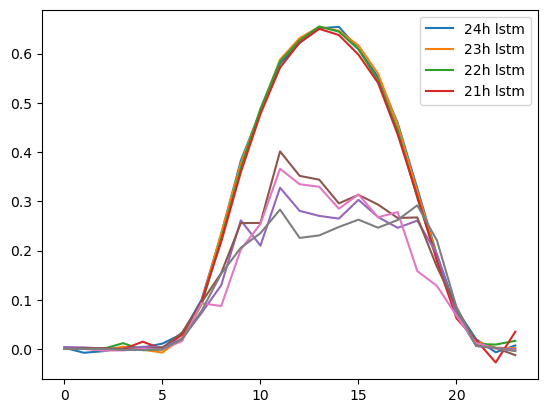

In [33]:
sample = 400

plt.plot(torch_py(pv_fcst_test_lstm[0][sample]), label='24h lstm')
plt.plot(np.pad(torch_py(pv_fcst_test_lstm[1][sample]), (1, 0), mode='constant'), label='23h lstm')
plt.plot(np.pad(torch_py(pv_fcst_test_lstm[2][sample]), (2, 0), mode='constant'), label='22h lstm')
plt.plot(np.pad(torch_py(pv_fcst_test_lstm[3][sample]), (3, 0), mode='constant'), label='21h lstm')

plt.plot(torch_py(pv_fcst_test_lstm_cvx[0][sample]))
plt.plot(np.pad(torch_py(pv_fcst_test_lstm_cvx[1][sample]), (1, 0), mode='constant'))
plt.plot(np.pad(torch_py(pv_fcst_test_lstm_cvx[2][sample]), (2, 0), mode='constant'))
plt.plot(np.pad(torch_py(pv_fcst_test_lstm_cvx[3][sample]), (3, 0), mode='constant'))

plt.legend()
plt.show()

In [184]:
# We keep the test initial batteries in this list
initial_battery_test_perfect = []
initial_battery_test_naive = []
initial_battery_test_lstm = []
initial_battery_test_cvx = []
initial_battery_test_lstm_cvx = []

pv_fcst_test_lstm = []
pv_fcst_test_cvx = []
pv_fcst_test_lstm_cvx = []

# These values get updated each loop
old_T = 24          # The first timeslot under consideration: 24 hours to optimize 
lags = 24           # The number of lags for this first timeslot: the 24 previous hours
forecast_gap = 0    # The gap after every forecast which is 0 when we need to forecast 24 hours

# loop over each of the problems
for i in range(problems):
       
    print('Setting up optimization for hour ' + str(i))
    
    # Get the optimization problem for the current problem
    problem, variables, parameters = pvb_system.create_optimization_problem(old_T)
    
    # Get what actually happens based on the (dis)charging scheme to obtain the initial battery value for the next hour
    problem_post, variables_post, parameters_post = pvb_system.create_post_forecast_optimization_problem(old_T)

    
    # Tensors for training a base forecaster
    tensors = tensor.Tensors(pvb_system.house,'solar_energy',past_features,future_features,lags,old_T, forecast_gap=forecast_gap,train_test_split=train_test_split)
    _, X_test, _, y_test, scalers = tensors.create_tensor()
    
    
    # Tensors for training an E2E network
    tensors_cvx = tensor.Tensors(pvb_system.house,'solar_energy',past_features,opt_future_features,lags,old_T, forecast_gap=forecast_gap, train_test_split=train_test_split, domain_min=domain_min, domain_max=domain_max)
    tensors_lstm_cvx = tensor.Tensors(pvb_system.house,'solar_energy',past_features,opt_future_features,lags,old_T, forecast_gap=forecast_gap, train_test_split=train_test_split, domain_min=domain_min, domain_max=domain_max)

    # We don't need the Y values as they are identical to the ones from the base forecaster
    _, X_test_perfect, _, _, scalers_perfect = tensors_cvx.create_tensor()
    _, X_test_naive, _, _, scalers_naive = tensors_cvx.create_tensor()
    _, X_test_lstm, _, _, scalers_lstm = tensors_cvx.create_tensor()
    _, X_test_cvx, _, _, scalers_cvx = tensors_cvx.create_tensor()
    _, X_test_lstm_cvx, _, _, scalers_lstm_cvx = tensors_lstm_cvx.create_tensor()

    # We have to assign initial battery values to the current optimization at hand, first we create an empty tensor
    initial_bat_tensor_test_perfect = torch.zeros([X_test_perfect.shape[0],lags,1])
    initial_bat_tensor_test_naive = torch.zeros([X_test_naive.shape[0],lags,1])
    initial_bat_tensor_test_lstm = torch.zeros([X_test_lstm.shape[0],lags,1])
    initial_bat_tensor_test_cvx = torch.zeros([X_test_cvx.shape[0],lags,1])
    initial_bat_tensor_test_lstm_cvx = torch.zeros([X_test_lstm_cvx.shape[0],lags,1])

    # If this is the first optimization done at midnight, the initial battery is set at 50% of the capacity, as we also make sure that the end
    # state of the battery from the previous day is 50%
    if i == 0:       
        initial_bat_tensor_test_perfect[:,-1,:] = battery_capacity * 0.5
        initial_bat_tensor_test_naive[:,-1,:] = battery_capacity * 0.5
        initial_bat_tensor_test_lstm[:,-1,:] = battery_capacity * 0.5
        initial_bat_tensor_test_cvx[:,-1,:] = battery_capacity * 0.5
        initial_bat_tensor_test_lstm_cvx[:,-1,:] = battery_capacity * 0.5

    # If it is not the first optimization, we obtain the initial battery values from the list of battery values we have been maintaining 
    else:
        initial_bat_tensor_test_perfect[:,-1,:] = torch.tensor(initial_battery_test_perfect[i-1]).unsqueeze(-1)
        initial_bat_tensor_test_naive[:,-1,:] = torch.tensor(initial_battery_test_naive[i-1]).unsqueeze(-1)
        initial_bat_tensor_test_lstm[:,-1,:] = torch.tensor(initial_battery_test_lstm[i-1]).unsqueeze(-1)
        initial_bat_tensor_test_cvx[:,-1,:] = torch.tensor(initial_battery_test_cvx[i-1]).unsqueeze(-1) 
        initial_bat_tensor_test_lstm_cvx[:,-1,:] = torch.tensor(initial_bat_tensor_test_lstm_cvx[i-1]).unsqueeze(-1)

    # We add this tensor to our X tensors for the E2E network
    X_test_perfect = torch.concat([X_test_perfect, initial_bat_tensor_test_perfect],dim=-1)
    X_test_naive = torch.concat([X_test_naive, initial_bat_tensor_test_naive],dim=-1)
    X_test_lstm = torch.concat([X_test_lstm, initial_bat_tensor_test_lstm],dim=-1)
    X_test_cvx = torch.concat([X_test_cvx, initial_bat_tensor_test_cvx],dim=-1)
    X_test_lstm_cvx = torch.concat([X_test_lstm_cvx, initial_bat_tensor_test_lstm_cvx],dim=-1)

    # Create the models for PV forecasts
    lstm = LSTM(features, neurons, layers, old_T, 0.5).to(device)
    cvx = LSTMOPT(features,neurons,layers,old_T,0.5,problem,parameters,variables,scalers_cvx[0]).to(device)
    lstm_cvx = LSTMOPT(features,neurons,layers,old_T,0.5,problem,parameters,variables,scalers_lstm_cvx[0]).to(device)

    lstm.load_state_dict(torch.load('../models/LSTM/building_' + str(building) + '_' + str(old_T) + 'h.pth'))
    cvx.load_state_dict(torch.load('../models/CVX/building_' + str(building) + '_' + str(old_T) + 'h_' + str(battery_capacity) + 'kwh.pth'))
    lstm_cvx.load_state_dict(torch.load('../models/CVX_LSTM/building_' + str(building) + '_' + str(old_T) + 'h_' + str(battery_capacity) + 'kwh.pth'))

    print('Forecasting PV')
    
    # Forecast the PV
    pv_perfect_test = y_test

    pv_naive_test = X_test[:,:,0]

    pv_lstm_test = lstm(X_test.to(device))

    pv_cvx_test, _ = cvx(X_test_cvx[:,:,0:-4].to(device),
                         X_test_cvx[:,-old_T:,-4].to(device),
                         X_test_cvx[:,-old_T:,-3].to(device),
                         X_test_cvx[:,-old_T:,-2].to(device),
                         X_test_cvx[:,-1,-1].to(device))

    pv_lstm_cvx_test, _ = lstm_cvx(X_test_lstm_cvx[:,:,0:-4].to(device),
                                   X_test_lstm_cvx[:,-old_T:,-4].to(device),
                                   X_test_lstm_cvx[:,-old_T:,-3].to(device),
                                   X_test_lstm_cvx[:,-old_T:,-2].to(device),
                                   X_test_lstm_cvx[:,-1,-1].to(device))


    # Make a list for the initial energy of the current timeslot for each day in the train and test sets
    perfect_test_initial_energy_t = []
    naive_test_initial_energy_t = []
    lstm_test_initial_energy_t = []
    cvx_test_initial_energy_t = []
    lstm_cvx_test_initial_energy_t = []

    print('Obtaining initial energy parameters for hour ' + str(i+1))
    
    # Loop over every day, first use the forecast of PV, next plug in the real PV and the charge and discharge schedules to obtain the real battery state
    for j in range(len(X_test)):   
        # Perfect forecast
        parameters[0].value = torch_py(rescale(pv_perfect_test[j], scalers_cvx[0]))
        parameters[1].value = torch_py(X_test_perfect[j,-old_T:,-4])
        parameters[2].value = torch_py(X_test_perfect[j,-old_T:,-3])
        parameters[3].value = torch_py(X_test_perfect[j,-old_T:,-2])
        parameters[4].value = torch_py(X_test_perfect[j,-1:,-1])[0]
        problem.solve()
        perfect_test_initial_energy_t.append(variables[-4].value[1])

        # Naive forecast
        parameters[0].value = torch_py(rescale(pv_naive_test[j], scalers_cvx[0]))
        parameters[1].value = torch_py(X_test_naive[j,-old_T:,-4])
        parameters[2].value = torch_py(X_test_naive[j,-old_T:,-3])
        parameters[3].value = torch_py(X_test_naive[j,-old_T:,-2])
        parameters[4].value = torch_py(X_test_naive[j,-1:,-1])[0]
        problem.solve()

        # Naive real
        parameters_post[0].value = torch_py(rescale(y_test[j,:], scalers[0]))
        parameters_post[1].value = torch_py(X_test_naive[j,-old_T:,-4])
        parameters_post[2].value = torch_py(X_test_naive[j,-old_T:,-3])
        parameters_post[3].value = torch_py(X_test_naive[j,-old_T:,-2])
        parameters_post[4].value = torch_py(X_test_naive[j,-1:,-1])[0]
        parameters_post[5].value = variables[-2].value
        parameters_post[6].value = variables[-1].value
        problem_post.solve()
        naive_test_initial_energy_t.append(variables_post[-1].value[1])

        # LSTM forecast
        parameters[0].value = torch_py(rescale(pv_lstm_test[j], scalers_cvx[0]))
        parameters[1].value = torch_py(X_test_lstm[j,-old_T:,-4])
        parameters[2].value = torch_py(X_test_lstm[j,-old_T:,-3])
        parameters[3].value = torch_py(X_test_lstm[j,-old_T:,-2])
        parameters[4].value = torch_py(X_test_lstm[j,-1:,-1])[0]
        problem.solve()

        # LSTM real
        parameters_post[0].value = torch_py(rescale(y_test[j,:], scalers[0]))
        parameters_post[1].value = torch_py(X_test_lstm[j,-old_T:,-4])
        parameters_post[2].value = torch_py(X_test_lstm[j,-old_T:,-3])
        parameters_post[3].value = torch_py(X_test_lstm[j,-old_T:,-2])
        parameters_post[4].value = torch_py(X_test_lstm[j,-1:,-1])[0]
        parameters_post[5].value = variables[-2].value
        parameters_post[6].value = variables[-1].value
        problem_post.solve()
        lstm_test_initial_energy_t.append(variables_post[-1].value[1])

        # CVX forecast
        parameters[0].value = torch_py(rescale(pv_cvx_test[j], scalers_cvx[0]))
        parameters[1].value = torch_py(X_test_cvx[j,-old_T:,-4])
        parameters[2].value = torch_py(X_test_cvx[j,-old_T:,-3])
        parameters[3].value = torch_py(X_test_cvx[j,-old_T:,-2])
        parameters[4].value = torch_py(X_test_cvx[j,-1:,-1])[0]
        problem.solve()
    
        # CVX real
        parameters_post[0].value = torch_py(rescale(y_test[j,:], scalers[0]))
        parameters_post[1].value = torch_py(X_test_cvx[j,-old_T:,-4])
        parameters_post[2].value = torch_py(X_test_cvx[j,-old_T:,-3])
        parameters_post[3].value = torch_py(X_test_cvx[j,-old_T:,-2])
        parameters_post[4].value = torch_py(X_test_cvx[j,-1:,-1])[0]
        parameters_post[5].value = variables[-2].value
        parameters_post[6].value = variables[-1].value
        problem_post.solve()
        cvx_test_initial_energy_t.append(variables_post[-1].value[1])

        # LSTM-CVX forecast
        parameters[0].value = torch_py(rescale(pv_lstm_cvx_test[j], scalers_cvx[0]))
        parameters[1].value = torch_py(X_test_lstm_cvx[j,-old_T:,-4])
        parameters[2].value = torch_py(X_test_lstm_cvx[j,-old_T:,-3])
        parameters[3].value = torch_py(X_test_lstm_cvx[j,-old_T:,-2])
        parameters[4].value = torch_py(X_test_lstm_cvx[j,-1:,-1])[0]
        problem.solve()

        # LSTM-CVX real
        parameters_post[0].value = torch_py(rescale(y_test[j,:], scalers[0]))
        parameters_post[1].value = torch_py(X_test_lstm_cvx[j,-old_T:,-4])
        parameters_post[2].value = torch_py(X_test_lstm_cvx[j,-old_T:,-3])
        parameters_post[3].value = torch_py(X_test_lstm_cvx[j,-old_T:,-2])
        parameters_post[4].value = torch_py(X_test_lstm_cvx[j,-1:,-1])[0]
        parameters_post[5].value = variables[-2].value
        parameters_post[6].value = variables[-1].value
        problem_post.solve()
        lstm_cvx_test_initial_energy_t.append(variables_post[-1].value[1])

    # Add the initial battery values to our list
    initial_battery_test_perfect.append(perfect_test_initial_energy_t)
    initial_battery_test_naive.append(naive_test_initial_energy_t)
    initial_battery_test_lstm.append(lstm_test_initial_energy_t)
    initial_battery_test_cvx.append(cvx_test_initial_energy_t)
    initial_battery_test_lstm_cvx.append(lstm_cvx_test_initial_energy_t)

    old_T += -1         # Update the timeslots we have to forecast, 1 less than the previous optimization
    lags += 1           # Update the lags we can use for the forecast, we still use the full previous day, but have 1 more hour of the current day as well
    forecast_gap += 1   # Add to the gap between forecasts (f.e. the gap is 1 if we only have to forecast 23 hours)